# Análisis de Influenciadores en Contrataciones Públicas

#### Carga de las librerías de Python necesarias

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from matplotlib.ticker import FuncFormatter

## 1. Conexión a SQL Server 

In [27]:
# Conexión a SQL Server con SQLAlchemy
conn_str = (
    "mssql+pyodbc://DESKTOP-N55HPMR/I_DE_NEGOCIOS_BD_NUEVO"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)
engine = create_engine(conn_str)

## 2. Análisis de Proveedores Clave

### Top 10 Proveedores por Monto

                                           proveedor tipo_proveedor  \
0                              CONSORCIO PTAP CALANA      Consorcio   
1                                    CONSORCIO SOLIN      Consorcio   
2  CONSORCIO QUÍMICA SUIZA S.A.C.  NOVO NORDISK P...      Consorcio   
3                              CONSORCIO SALUD PETRA      Consorcio   
4  CONSORCIO QUÍMICA SUIZA S.A.C.  SHIRE PERÚ S.A.C.      Consorcio   
5                               CONSORCIO 5 ESQUINAS      Consorcio   
6  CONSORCIO QUÍMICA PERUANA S.A.C. NOVO NORDISK ...      Consorcio   
7                                CONSORCIO LUNAHUANA      Consorcio   
8                              CONSORCIO MODULAR MSC      Consorcio   
9                     CONSORCIO CONSTRUCTOR CENTRO I      Consorcio   

    monto_total  cantidad_contratos  
0 1176136800.12                  18  
1  892974374.71                  11  
2  757018702.44                  26  
3  695115063.36                  18  
4  538279372.80             

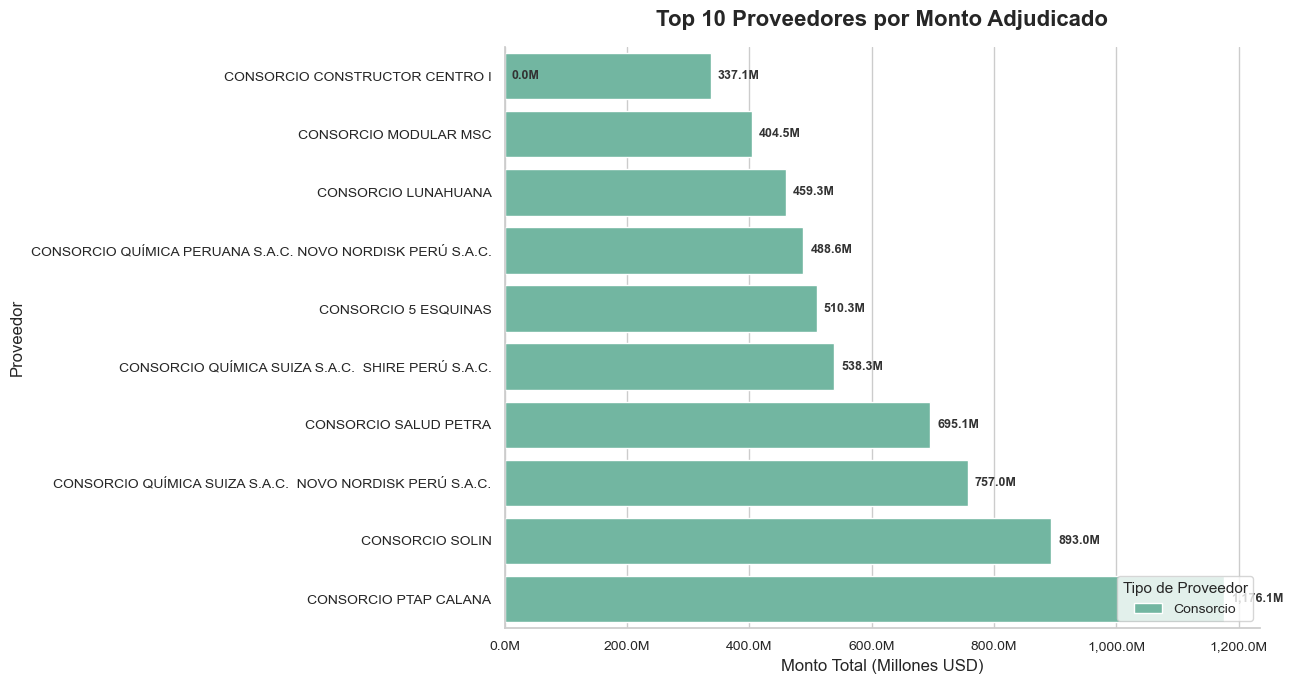

In [32]:
query_proveedores = """
SELECT TOP 10
    p.proveedor,
    p.tipo_proveedor,
    SUM(h.monto_adjudicado_item) AS monto_total,
    COUNT(h.id_hecho) AS cantidad_contratos
FROM hechos_contrataciones h
JOIN dim_proveedor p ON h.id_proveedor = p.id_proveedor
GROUP BY p.proveedor, p.tipo_proveedor
ORDER BY monto_total DESC
"""

df_proveedores = pd.read_sql(query_proveedores, engine)
print(df_proveedores)
# Visualización
df_top10 = df_proveedores.sort_values('monto_total', ascending=True).tail(10)
# Estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(13, 7))

# Gráfico de barras horizontales
ax = sns.barplot(
    data=df_top10,
    x='monto_total',
    y='proveedor',
    hue='tipo_proveedor',
    dodge=False,
    palette='Set2'
)

# Formatear eje X en millones
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:,.1f}M'))

# Título y etiquetas
ax.set_title('Top 10 Proveedores por Monto Adjudicado', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Monto Total (Millones USD)', fontsize=12)
ax.set_ylabel('Proveedor', fontsize=12)
ax.tick_params(labelsize=10)
ax.spines[['top', 'right']].set_visible(False)

# Añadir etiquetas de valor al final de cada barra
for bar in ax.patches:
    ancho = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        ancho + max(df_top10['monto_total']) * 0.01,
        y,
        f'{ancho/1e6:,.1f}M',
        va='center',
        ha='left',
        fontsize=9,
        color='#333333',
        fontweight='bold'
    )

# Leyenda ajustada
ax.legend(title='Tipo de Proveedor', loc='lower right', frameon=True, fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

## 3. Análisis de Redes (Entidades-Proveedores)

In [33]:
query_relaciones = """
SELECT 
    e.entidad,
    p.proveedor,
    SUM(h.monto_adjudicado_item) AS monto_total
FROM hechos_contrataciones h
JOIN dim_entidad e ON h.id_entidad = e.id_entidad
JOIN dim_proveedor p ON h.id_proveedor = p.id_proveedor
GROUP BY e.entidad, p.proveedor
"""

df_relaciones = pd.read_sql(query_relaciones, engine)

# Crear grafo dirigido (las entidades adjudican a proveedores)
G = nx.from_pandas_edgelist(
    df_relaciones,
    source='entidad',
    target='proveedor',
    edge_attr='monto_total',
    create_using=nx.DiGraph()
)

# Calcular métricas de centralidad
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G, weight='monto_total')

# Identificar nodos clave
top_entidades = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:5]
top_proveedores = sorted(betweenness_cent.items(), key=lambda x: x[1], reverse=True)[:5]
top_influyentes = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:5]

print("🔷 Entidades más activas (grado de centralidad):")
for entidad, score in top_entidades:
    print(f"- {entidad} (Score: {score:.4f})")

print("\n🔶 Proveedores más estratégicos (intermediación):")
for proveedor, score in top_proveedores:
    print(f"- {proveedor} (Score: {score:.4f})")

print("\n💎 Actores más influyentes (PageRank ponderado por monto):")
for actor, score in top_influyentes:
    print(f"- {actor} (Score: {score:.4f})")

🔷 Entidades más activas (grado de centralidad):
- SEGURO SOCIAL DE SALUD (Score: 0.0757)
- IAFAS DEL EJERCITO DEL PERU (FOSPEME) (Score: 0.0246)
- POLICÍA NACIONAL DEL PERÚ - DIRECCIÓN DE SANIDAD (Score: 0.0210)
- GOBIERNO REGIONAL DE PIURA - PROYECTO ESPECIAL CHIRA PIURA (Score: 0.0210)
- UNIDAD EJECUTORA 125 PROGRAMA NACIONAL DE INVERSIONES EN SALUD (Score: 0.0201)

🔶 Proveedores más estratégicos (intermediación):
- EJERCITO PERUANO (Score: 0.0000)
- AERO ENGINEERING SAC - AEROMASTER AIRWAYS SA (Score: 0.0000)
- INSTITUTO NACIONAL DE SALUD DEL NIÑO (Score: 0.0000)
- AIR CONDITIONING TECHNOLOGY SISTEM SAC - G & C SUPPORTMEDICAL E.I.R.L. (Score: 0.0000)
- GOBIERNO REGIONAL DE LA LIBERTAD - HOSPITAL REGIONAL DOCENTE DE TRUJILLO (Score: 0.0000)

💎 Actores más influyentes (PageRank ponderado por monto):
- CONSORCIO PERU (Score: 0.0020)
- CONSORCIO SAN MARTIN (Score: 0.0019)
- CONSORCIO SAN FRANCISCO (Score: 0.0018)
- CONSORCIO PACIFICO (Score: 0.0017)
- CONSORCIO LA POSITIVA (Score: 0.001

## 4. Segmentación de Proveedores

### Clustering por Monto vs. Frecuencia

C:\Users\Ronny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


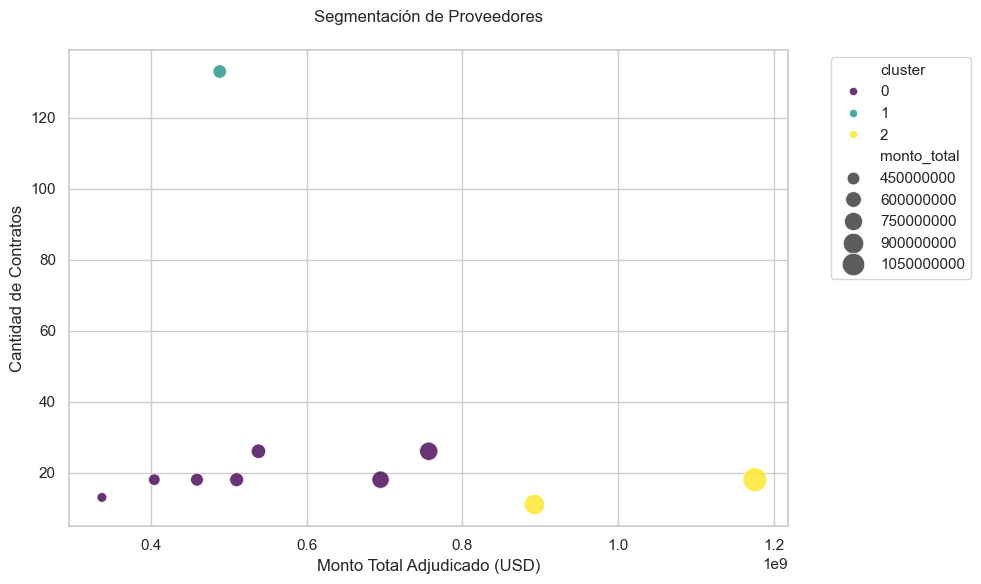


📊 Caracterización de Clusters:
        monto_total                                                       \
              count          mean          std          min          25%   
cluster                                                                    
0              7.00  528791665.81 151220462.34 337141438.40 431866810.08   
1              1.00  488563481.38          NaN 488563481.38 488563481.38   
2              2.00 1034555587.41 200226071.18 892974374.71 963764981.06   

                                                  cantidad_contratos         \
                  50%           75%           max              count   mean   
cluster                                                                       
0        510253463.52  616697218.08  757018702.44               7.00  19.57   
1        488563481.38  488563481.38  488563481.38               1.00 133.00   
2       1034555587.41 1105346193.77 1176136800.12               2.00  14.50   

                                    

In [44]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Verifica que las columnas existan en df_proveedores
required_columns = ['monto_total', 'cantidad_contratos']
for col in required_columns:
    if col not in df_proveedores.columns:
        raise ValueError(f"La columna '{col}' no existe en df_proveedores. Asegúrate de crearla antes.")

# Escalado de datos
scaler = StandardScaler()
X = scaler.fit_transform(df_proveedores[required_columns])

# Clustering K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df_proveedores['cluster'] = kmeans.fit_predict(X)

# Visualización
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_proveedores,
    x='monto_total',
    y='cantidad_contratos',
    hue='cluster',
    size='monto_total',
    sizes=(50, 300),
    alpha=0.8,
    palette='viridis'
)
plt.title('Segmentación de Proveedores', pad=20)
plt.xlabel('Monto Total Adjudicado (USD)')
plt.ylabel('Cantidad de Contratos')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Descripción de clusters
print("\n📊 Caracterización de Clusters:")
print(df_proveedores.groupby('cluster')[['monto_total', 'cantidad_contratos']].describe())

## 5. Evolución Temporal de Proveedores Clave

      año                                          proveedor   monto_total
0 2021.00                              CONSORCIO PTAP CALANA 1176136800.12
1 2022.00  CONSORCIO QUÍMICA SUIZA S.A.C.  NOVO NORDISK P...  757018702.44
2 2022.00  CONSORCIO QUÍMICA SUIZA S.A.C.  SHIRE PERÚ S.A.C.  538279372.80
3 2023.00                                    CONSORCIO SOLIN  892974374.71
4 2024.00                              CONSORCIO SALUD PETRA  695115063.36


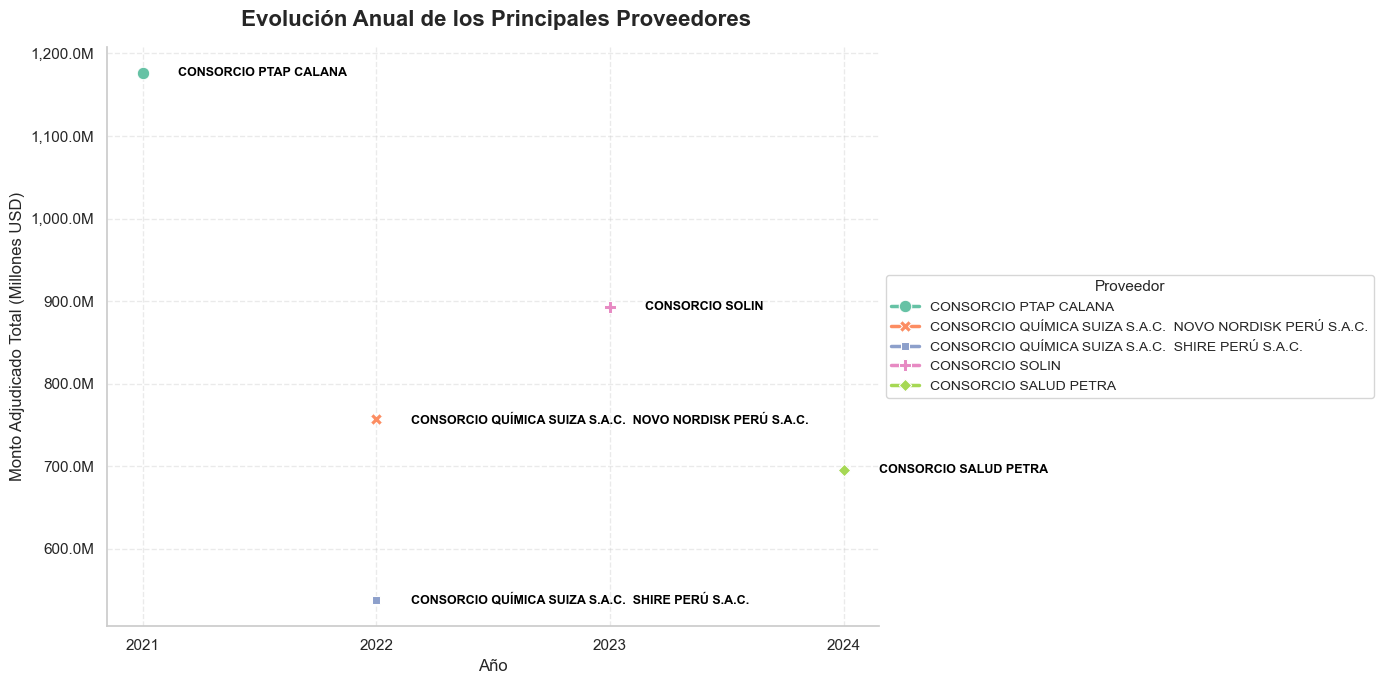

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import locale

# Consulta SQL
query_evolucion = f"""
SELECT 
    h.año,
    p.proveedor,
    SUM(h.monto_adjudicado_item) AS monto_total
FROM hechos_contrataciones h
JOIN dim_proveedor p ON h.id_proveedor = p.id_proveedor
WHERE p.proveedor IN ({proveedores_in})
GROUP BY h.año, p.proveedor
ORDER BY h.año, monto_total DESC
"""

# Cargar datos
df_evolucion = pd.read_sql(query_evolucion, engine)
print(df_evolucion)
# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))
ax = sns.lineplot(
    data=df_evolucion,
    x='año',
    y='monto_total',
    hue='proveedor',
    style='proveedor',
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=9,
    palette='Set2'
)

# Eje Y en millones
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:,.1f}M'))

# Estética del gráfico
ax.set_title(' Evolución Anual de los Principales Proveedores', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Monto Adjudicado Total (Millones USD)', fontsize=12)
ax.tick_params(labelsize=11)
ax.set_xticks(sorted(df_evolucion['año'].unique()))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)

# Etiquetas cerca del último punto de cada línea
for proveedor in df_evolucion['proveedor'].unique():
    datos = df_evolucion[df_evolucion['proveedor'] == proveedor].sort_values('año')
    ultimo = datos.iloc[-1]
    ax.text(
        x=ultimo['año'] + 0.15,
        y=ultimo['monto_total'],
        s=proveedor,
        fontsize=9,
        fontweight='bold',
        color='black',
        va='center'
    )

# Leyenda
ax.legend(title='Proveedor', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=True, fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

## 6. Análisis de Entidades por Departamento

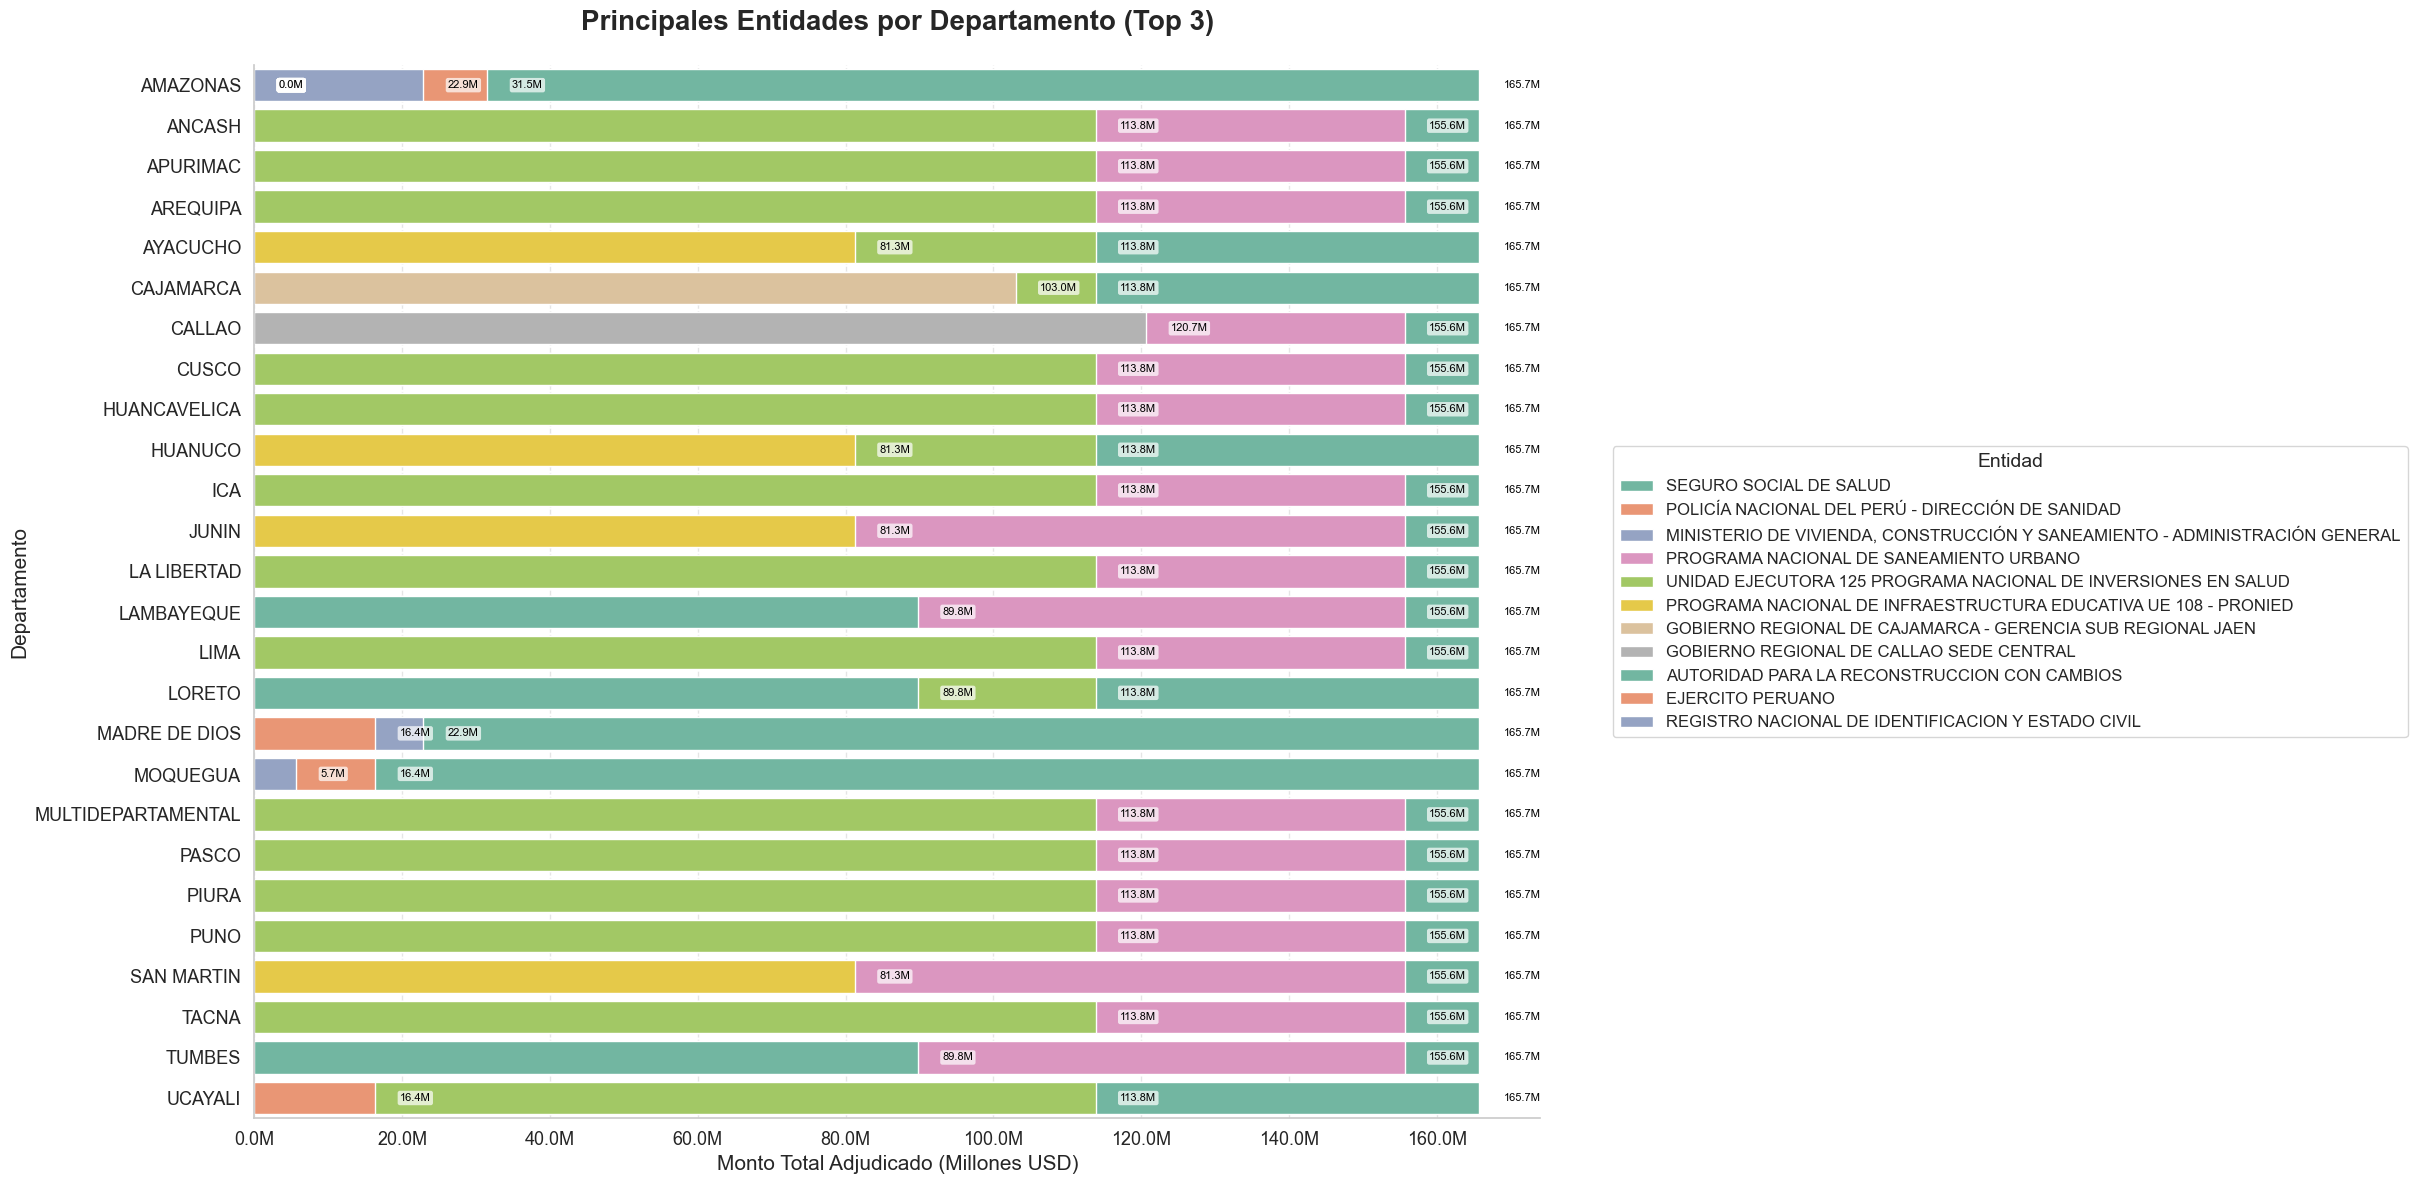

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Supón que ya tienes 'top_dept' y todo preparado

# Configuración visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(26, 12))  # Agrandar todo para barras más largas

# Gráfico de barras horizontales con barras más gruesas
ax = sns.barplot(
    data=top_dept,
    x='monto_total',
    y='departamento',
    hue='entidad',
    dodge=False,
    palette='Set2'
)

# Formato del eje x en millones
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Títulos y etiquetas
ax.set_title('Principales Entidades por Departamento (Top 3)', fontsize=20, fontweight='bold', pad=25)
ax.set_xlabel('Monto Total Adjudicado (Millones USD)', fontsize=15)
ax.set_ylabel('Departamento', fontsize=15)
ax.tick_params(labelsize=13)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

# Texto en barra con menor tamaño y fondo
max_value = top_dept['monto_total'].max() if not top_dept['monto_total'].isnull().all() else 0

for bar in ax.patches:
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        x + max_value * 0.02,
        y,
        f'{x/1e6:.1f}M',
        va='center',
        fontsize=8,  # menor tamaño
        color='black',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2')  # fondo
    )

# Ajustar la posición y tamaño de la leyenda para que esté más a la derecha y más grande
ax.legend(
    title='Entidad',
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),  # más a la derecha
    frameon=True,
    fontsize=12,
    title_fontsize=14
)

# Uso de tight_layout para ajustar todo y añadir espacio extra a la derecha
plt.tight_layout(rect=[0, 0, 0.95, 1])  # aumenta espacio en el lado derecho

plt.show()